 # ML Workflow

  Dataset
    →
  Understand columns
    →
  Clean data
    →
  Handle missing values
    →
  EDA
    →
  Identify target column
    →
  Separate X and y
    →
  Encode categorical columns
    →
  Train/Test Split
    →
  Feature Scaling (if required)
    →
  Train ML model
    →
  Prediction
    →
  Evaluate model

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Importing the dataset from the kagges


In [82]:
import kagglehub
import os
path = kagglehub.dataset_download("moro146/supermarket-eda")

Using Colab cache for faster access to the 'supermarket-eda' dataset.


Create a dataframe for the import data


In [83]:
df = pd.read_table(os.path.join(path, "supermarket.csv"), sep=",")

In [84]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [86]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [87]:
df['Sales'].value_counts()

,count
Sales,
12.960,55
19.440,39
15.552,39
10.368,35
25.920,34
...,...
2.496,1
10.984,1
364.080,1


In [88]:
df.dropna(inplace=True)

In [89]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [90]:
df.describe()

,Row ID,Postal Code,Sales
count,9789.000000,9789.000000,9789.000000
mean,4896.705588,55273.322403,230.116193
std,2827.486899,32041.223413,625.302079
min,1.000000,1040.000000,0.444000
25%,2449.000000,23223.000000,17.248000
50%,4896.000000,58103.000000,54.384000
75%,7344.000000,90008.000000,210.392000
max,9800.000000,99301.000000,22638.480000


### Pairplot for Numerical Features

A pairplot creates a grid of scatterplots for pairwise relationships between numerical features and histograms for the distribution of each individual feature. This can help in identifying skewness visually in the histograms on the diagonal.

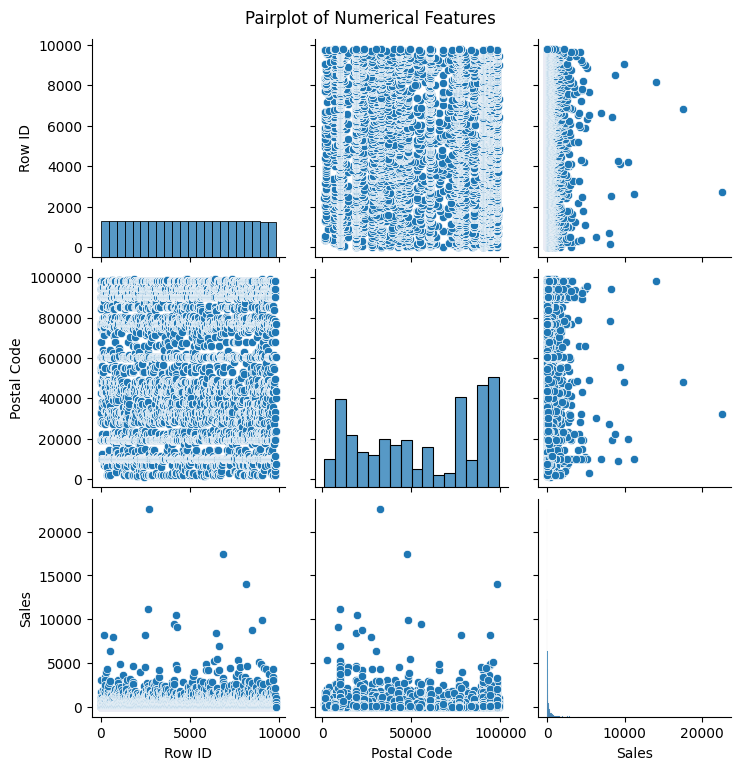

In [91]:
# Select only numerical columns for the pairplot
numerical_cols = df.select_dtypes(include=np.number).columns

# Generate the pairplot
fig = sns.pairplot(df[numerical_cols])
plt.suptitle('Pairplot of Numerical Features', y=1.02) # Add a title to the plot
plt.show()

### Correlation Heatmap

A heatmap is a graphical representation of data where the individual values contained in a matrix are represented as colors. It's excellent for visualizing the correlation matrix, showing the strength and direction of relationships between numerical variables.

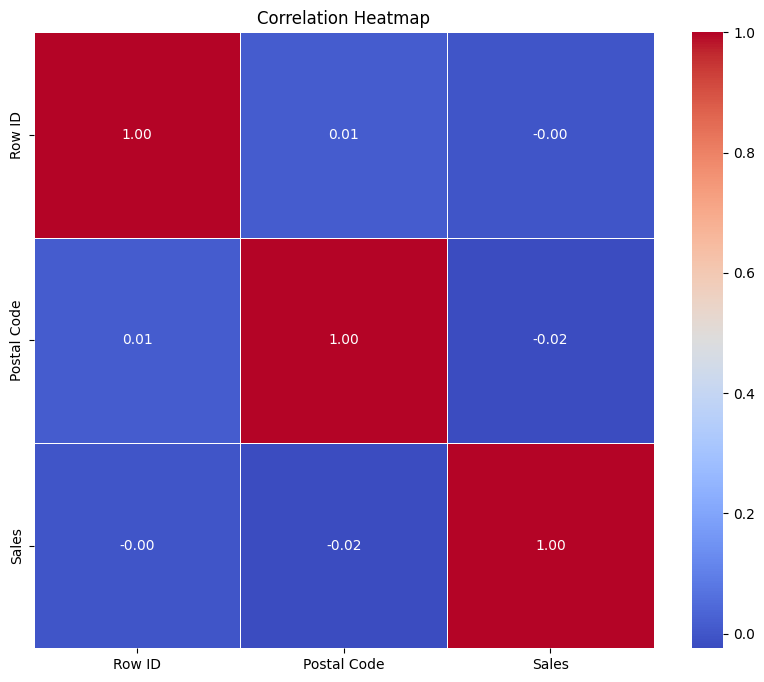

In [92]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

### Skewness Visualization for 'Sales' Column

To visually understand the skewness, a distribution plot with a Kernel Density Estimate (KDE) overlay is very effective. It shows the shape of the data distribution, highlighting if it's skewed to the left or right.

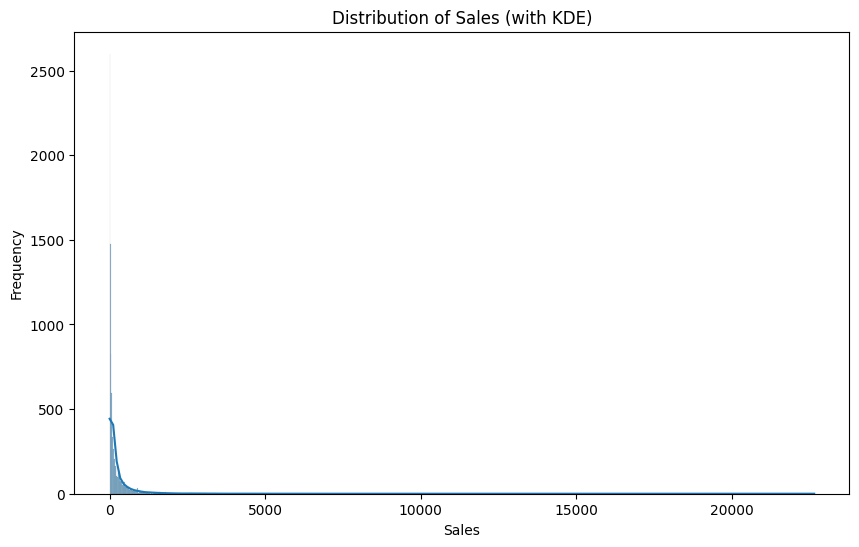

In [93]:
# Create a distribution plot for the 'Sales' column
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], kde=True)
plt.title('Distribution of Sales (with KDE)')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

by this chart i can see that sales columns is show high right shweness so i will fix this by log or log1p

# flow
Original DataFrame
       →
Check skewness
       →
df['Sales'].skew()
       →
Sales is highly right-skewed
       →
np.log1p(df['Sales'])
       →
Check skewness again

In [94]:
print("Before:", df['Sales'].skew())

Before: 13.053630955201138


In [95]:
df['Sales'] = np.log1p(df['Sales'])

In [96]:
print("After:", df['Sales'].skew())

After: 0.2809213422697102


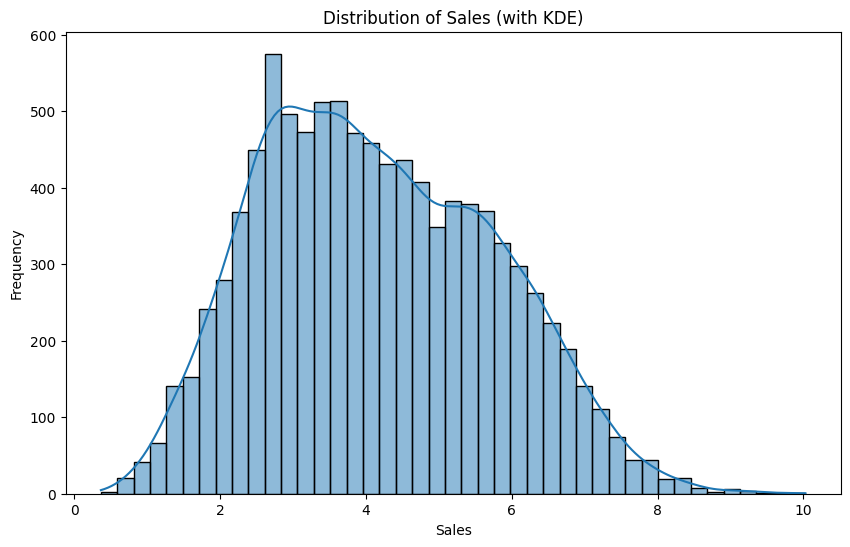

In [97]:
# Create a distribution plot for the 'Sales' column
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], kde=True)
plt.title('Distribution of Sales (with KDE)')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

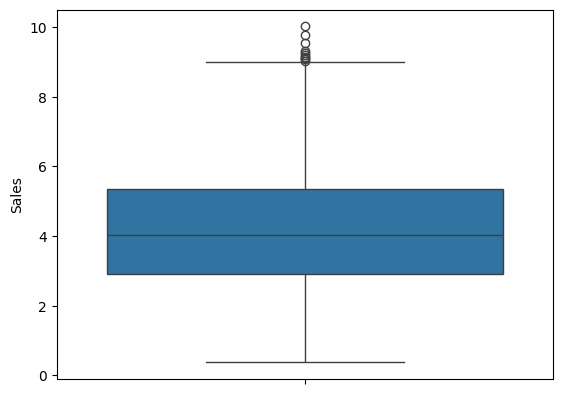

In [98]:
sns.boxplot(df['Sales'])
plt.show()

handle outliers

In [99]:
# Q1 = df['Sales'].quantile(0.25)
# Q3 = df['Sales'].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR
# print("Lower:", lower)
# print("Upper:", upper)
# outliers = df[(df['Sales'] < lower) | (df['Sales'] > upper)]
# print("Number of outliers:", len(outliers))
# print("Percentage:", len(outliers) / len(df) * 100)

removeing unwanted colunms


In [100]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Order Weekday'] = df['Order Date'].dt.dayofweek

In [101]:
drop_cols = [
    'Row ID',
    'Order ID',
    'Customer ID',
    'Customer Name',
    'Product ID',
    'Order Date',
    'Ship Date'
]

df = df.drop(columns=drop_cols)

In [102]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
print("Numerical:")
print(num_cols)
print("\nCategorical:")
print(cat_cols)

Numerical:
Index(['Postal Code', 'Sales', 'Ship Days', 'Order Year', 'Order Month',
       'Order Quarter', 'Order Weekday'],
      dtype='object')

Categorical:
Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region',
       'Category', 'Sub-Category', 'Product Name'],
      dtype='object')


Appleing Ordinal Encoder on X

In [103]:
# def Encoder(model):
#   df[cat_cols] = model.fit_transform(X[cat_cols])
#   return model

In [104]:
# from sklearn.preprocessing import OrdinalEncoder
# oe=Encoder(OrdinalEncoder())

Appleing One Hot Encoder on X

In [105]:
from sklearn.preprocessing import OneHotEncoder

# Only encode if there are categorical columns to encode
if not cat_cols.empty:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    ohe.set_output(transform="pandas")
    encoded_df = ohe.fit_transform(df[cat_cols])
    # Drop original categorical columns from X and concatenate encoded ones
    df = pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)
    print("Categorical columns encoded and X updated.")
else:
    print("No categorical columns to encode in X.")


Categorical columns encoded and X updated.


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Columns: 2464 entries, Postal Code to Product Name_netTALK DUO VoIP Telephone Service
dtypes: float64(2459), int32(4), int64(1)
memory usage: 183.9 MB


In [109]:
# '''
# # Encoder without ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder
# ohe=OneHotEncoder(sparse_output=False, handle_unknown="ignore")
# ohe.set_output(transform="pandas")
# encoded_df = ohe.fit_transform(X[cat_cols])
# X = pd.concat([X[num_cols], encoded_df], axis=1)

# # Encoder with ColumnTransformer
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
#     ],
#     remainder='passthrough'
# )
# X_train_encoded = preprocessor.fit_transform(X_train)
# X_test_encoded = preprocessor.transform(X_test)
# '''

In [107]:
X = df.drop('Sales', axis=1)
y = df['Sales']

apple x_train,x_test,y_train and y_test on dataset

In [108]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [110]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [111]:
models = []
r2_scores = []

In [112]:
def mynewmodel():
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    from sklearn.metrics import r2_score

    models.append(('LinearRegression', LinearRegression()))
    models.append(('Decision Tree', DecisionTreeRegressor()))

    for name, model in models:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        r2 = r2_score(y_test, predictions)
        print(f"Name of Model: {name}")
        print(f"  R-squared: {r2}")
        train = model.score(X_train, y_train)
        test = model.score(X_test, y_test)
        print(f"  Training score: {train}")
        print(f"  Testing score: {test}")
        print("")
        r2_scores.append(r2)

    arr=np.array(r2_scores)
    print(f"Average R-squared score: {arr.mean()}")

In [113]:
run = mynewmodel()

Name of Model: LinearRegression
  R-squared: 0.7605219197878752
  Training score: 0.9052612609387183
  Testing score: 0.7605219197878752

Name of Model: Decision Tree
  R-squared: 0.5526619095530944
  Training score: 0.9999467287522259
  Testing score: 0.5526619095530944

Average R-squared score: 0.6565919146704848


In [114]:
def mymodel(model):
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  from sklearn.metrics import r2_score
  r2 = r2_score(y_test, y_pred)
  train=model.score(X_train,y_train)
  test=model.score(X_test,y_test)
  print("R-squared:", r2)
  print(f"Training score: {train}")
  print(f"Testing score: {test}")
  return model

In [115]:
linreg = mymodel(LinearRegression())

R-squared: 0.7605219197878752
Training score: 0.9052612609387183
Testing score: 0.7605219197878752


In [116]:
from sklearn.linear_model import Lasso
lasso = mymodel(Lasso(alpha=10))

R-squared: -0.0003127090838619395
Training score: 2.3400560277941906e-05
Testing score: -0.0003127090838619395


In [117]:
from sklearn.linear_model import Ridge
ridge = mymodel(Ridge(alpha=2))

R-squared: 0.7414662680566777
Training score: 0.8509800689601965
Testing score: 0.7414662680566777
